# 자동차 OBD 센서 데이터로 고장 분류하기

한국어 설명과 주석을 포함한 머신러닝 실습입니다. 이 노트북에서는 **Random Forest 학습과 테스트 평가까지 실행**합니다. 앞서 만든 모터 전류 데이터와는 별개의 프로젝트입니다.

데이터 출처: [AbouAbdallah-Lounis/OBD-Dataset](https://github.com/AbouAbdallah-Lounis/OBD-Dataset) · 고정 커밋 `a9c96dc146aeeb62ef75d3b453c238f5379ccff5`.

원저자: Karim Lounis, Hadjer Mekki, Wissam Hadjab, *DieselOBD*, 2025. 저장소 README에 명시된 라이선스는 [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/)입니다. 이 실습은 중복 정리와 분류 모델을 추가했습니다.

**목표**: 11개 센서값으로 ① 정상/고장 여부, ② 동시에 존재할 수 있는 여러 DTC 코드를 예측합니다. 고장 발생까지 남은 시간을 예측하는 실습은 아닙니다.

실행 방법: 프로젝트의 `.venv` 파이썬 커널을 선택하고 위에서부터 모든 셀을 실행하세요. 표준 주피터 확장자는 `.ipynb`이므로 요청한 이름을 `test01.ipynb`로 만들었습니다.

## 1. 라이브러리와 경로
필요한 패키지는 현재 `.venv`에 설치되어 있습니다. 다른 환경에서는 아래 주석의 설치 명령을 사용하세요. 난수 시드를 고정하여 같은 환경에서 결과를 재현합니다.

In [8]:
# 필요한 경우 아래 한 줄의 주석을 해제하고 실행하세요.
# %pip install pandas numpy openpyxl scikit-learn matplotlib joblib

from pathlib import Path
import os
import json
import hashlib
import urllib.request

ROOT = Path.cwd()
DATA_DIR = ROOT / "obd_dataset"
OUTPUT_DIR = ROOT / "results" / "test01"
DATA_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
# matplotlib 캐시는 프로젝트 안에 둡니다.
os.environ.setdefault("MPLCONFIGDIR", str(OUTPUT_DIR / "mplconfig"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import joblib
from IPython.display import display
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, classification_report, ConfusionMatrixDisplay, hamming_loss,
)

SEED = 42
pd.set_option("display.max_columns", 32)
print("scikit-learn:", sklearn.__version__)
print("프로젝트 경로:", ROOT)

scikit-learn: 1.9.1
프로젝트 경로: /Users/hangyeonghyeon/Desktop/Py/python_study


## 2. 데이터 다운로드와 무결성 확인
이미 내려받은 파일은 그대로 사용합니다. 파일이 없으면 고정된 커밋에서 다운로드합니다. SHA-256으로 다운로드한 내용이 이번 실습의 원본과 같은지 확인합니다. 저장소의 외부 파이썬 코드는 실행하지 않습니다.

In [9]:
COMMIT = "a9c96dc146aeeb62ef75d3b453c238f5379ccff5"
BASE_URL = f"https://raw.githubusercontent.com/AbouAbdallah-Lounis/OBD-Dataset/{COMMIT}"
EXPECTED_SHA256 = {'MASTER_TEST_X.xlsx': '9f4047f5964a450e03fa96de4b4927c09171998713e4222e5285cae3a0c1b1d4', 'README.md': '3ee22525a547950d479a5494a837cbdb501baa2a54d817766ebdbeddb61643e7', 'MASTER_TRAIN_X.xlsx': '4af148292731d3e16429a71fc4edd4de060930e9a0e2476f9389214c8bb9af32'}

for filename, expected_hash in EXPECTED_SHA256.items():
    path = DATA_DIR / filename
    if not path.exists():
        # 임시 파일에 내려받아 완료된 파일만 원본 이름으로 옮깁니다.
        temporary = path.with_suffix(path.suffix + ".download")
        with urllib.request.urlopen(f"{BASE_URL}/{filename}", timeout=120) as response:
            temporary.write_bytes(response.read())
        temporary.replace(path)
    actual_hash = hashlib.sha256(path.read_bytes()).hexdigest()
    if actual_hash != expected_hash:
        raise ValueError(f"원본 해시가 다릅니다: {filename}. 원본을 확인하세요.")
    print(f"확인 완료: {filename} ({path.stat().st_size:,} bytes)")

확인 완료: MASTER_TEST_X.xlsx (2,531,527 bytes)
확인 완료: README.md (6,643 bytes)
확인 완료: MASTER_TRAIN_X.xlsx (8,995,072 bytes)


## 3. 원본 엑셀 읽기와 구조 확인
저장소가 제공한 Train/Test 구분을 그대로 사용합니다. 새 무작위 분할을 만들지 않습니다. 엑셀 읽기는 환경에 따라 1~2분 걸릴 수 있습니다.

실제 엑셀은 11개 PID 센서 열, 14개 P-code 열, Mode 열로 구성되어 있습니다. README의 예시와 달리 차량 ID와 타임스탬프는 엑셀에 없습니다. Mode의 의미는 확인되지 않았으므로 입력에서 제외합니다. 온도·압력 등의 단위는 README 설명과 실제 값의 범위를 대조할 필요가 있어 임의로 변환하지 않습니다.

In [3]:
# 원본 데이터는 수정하지 않습니다.
train_raw = pd.read_excel(DATA_DIR / "MASTER_TRAIN_X.xlsx", sheet_name="Train")
test_raw = pd.read_excel(DATA_DIR / "MASTER_TEST_X.xlsx", sheet_name="Test")
print("원본 학습 데이터:", train_raw.shape)
print("원본 테스트 데이터:", test_raw.shape)
display(train_raw.head())
display(train_raw.describe().T)

원본 학습 데이터: (118477, 26)
원본 테스트 데이터: (33838, 26)


,LOAD_PCT,ECT,MAP,RPM,VSS,IAT,MAF,FRP,BARO,VPWR,AAT,P0000,P0562,P0113,P0102,P0403,P0404,P2562,P0234,P2015,P2009,P0107,P0069,P0089,P0406,Mode
0,26.3,169,14.4,790,0.0,106,0.02,4507.5,14.2,13.64,126,0,0,0,0,1,1,0,0,1,1,0,0,0,0,0
1,26.3,169,14.4,790,0.0,106,0.02,4507.5,14.2,13.64,126,0,0,0,0,1,1,0,0,1,1,0,0,0,0,0
2,26.3,169,14.4,790,0.0,106,0.02,4507.5,14.2,13.64,126,0,0,0,0,1,1,0,0,1,1,0,0,0,0,0
3,26.3,169,14.4,790,0.0,106,0.02,4507.5,14.2,13.64,126,0,0,0,0,1,1,0,0,1,1,0,0,0,0,0
4,26.3,169,14.4,790,0.0,106,0.02,4507.5,14.2,13.64,126,0,0,0,0,1,1,0,0,1,1,0,0,0,0,0


,count,mean,std,min,25%,50%,75%,max
LOAD_PCT,118477.0,29.714112,25.144105,0.00,12.90,23.900,40.400,100.000
ECT,118477.0,174.974907,27.710932,72.00,153.00,189.000,196.000,241.000
MAP,118477.0,15.343869,5.652406,2.80,14.60,15.200,17.700,37.000
RPM,118477.0,1407.254193,562.089371,702.00,793.00,1443.000,1811.000,3174.000
VSS,118477.0,38.133335,36.169404,0.00,0.00,26.000,72.405,133.547
IAT,118477.0,91.602235,22.324852,46.00,75.00,88.000,106.000,144.000
MAF,118477.0,0.049710,0.031582,0.01,0.03,0.040,0.060,0.260
FRP,118477.0,7626.851117,4449.929902,2520.60,3886.80,6182.600,10659.700,21624.000
BARO,118477.0,14.415853,0.142782,14.10,14.40,14.400,14.500,14.600
VPWR,118477.0,14.106128,0.502639,12.28,14.08,14.179,14.420,14.760


## 4. 입력 X와 정답 y 정의
`P0000`은 이 데이터의 정상 표시이고 나머지 P-code는 고장 라벨입니다. **P-code를 입력에 넣으면 정답 누출**이 생기므로 센서 열만 명시적으로 선택합니다. VPWR은 P로 시작하지만 전압 센서이므로 센서 목록으로 구분합니다.

여러 고장 코드가 한 행에 동시에 존재할 수 있으므로 단일 클래스 분류가 아닌 다중 라벨 분류도 수행합니다. 이 실습에서는 P0000=1이고 다른 코드가 없는 행을 정상, P0000=0이고 고장 코드가 있는 행을 고장으로 사용합니다. 실제 파일에는 전체 라벨이 0인 행이나 정상과 고장이 함께 표시된 행이 있을 수 있습니다. 이 행들은 정상으로 임의 변환하지 않고 문제 목록에 원래 값 그대로 저장한 뒤 학습/평가에서 제외합니다. 개수와 사유는 출력합니다.

In [4]:
SENSOR_COLS = ["LOAD_PCT", "ECT", "MAP", "RPM", "VSS", "IAT", "MAF", "FRP", "BARO", "VPWR", "AAT"]
LABEL_COLS = ["P0000", "P0562", "P0113", "P0102", "P0403", "P0404", "P2562",
              "P0234", "P2015", "P2009", "P0107", "P0069", "P0089", "P0406"]
FAULT_COLS = [c for c in LABEL_COLS if c != "P0000"]

label_audit = {}
label_eligible = {}
for split_name, frame in [("Train", train_raw), ("Test", test_raw)]:
    absent = set(SENSOR_COLS + LABEL_COLS) - set(frame.columns)
    if absent:
        raise ValueError(f"{split_name} 필수 열 누락: {absent}")
    # 라벨 누락이나 잘못된 값을 정상(0)으로 채우지 않습니다.
    labels = frame[LABEL_COLS].apply(pd.to_numeric, errors="coerce")
    if labels.isna().any().any() or not labels.isin([0, 1]).all().all():
        raise ValueError(f"{split_name} 라벨은 누락 없는 0/1이어야 합니다.")
    fault = labels[FAULT_COLS].any(axis=1)
    # 원본 라벨은 수정하지 않습니다. 전체 0인 행은 정상으로 단정할 수 없습니다.
    healthy_mark = labels["P0000"].eq(1)
    conflict = healthy_mark & fault
    unknown = ~healthy_mark & ~fault
    eligible = ~conflict & ~unknown
    label_eligible[split_name] = eligible
    label_audit[split_name] = {
        "healthy_and_fault_rows": int(conflict.sum()),
        "all_zero_label_rows": int(unknown.sum()),
        "eligible_rows": int(eligible.sum()),
    }
    # 문제가 있는 행을 따로 저장하고, 정답이 확인되는 행만 학습/평가에 사용합니다.
    issues = frame.loc[~eligible].copy()
    issues.insert(0, "source_row", frame.index[~eligible])
    issues["label_issue"] = np.where(conflict.loc[~eligible],
                                     "healthy_and_fault", "all_labels_zero")
    issues.to_csv(OUTPUT_DIR / f"{split_name.lower()}_label_issues.csv",
                  index=False, encoding="utf-8-sig")
    print(f"{split_name} 라벨 점검:", label_audit[split_name])
    if not eligible.any():
        raise ValueError(f"{split_name}에 정답을 확인할 수 있는 행이 없습니다.")

display(pd.DataFrame(label_audit).T)

support = pd.DataFrame({"Train_positive": train_raw[LABEL_COLS].sum(),
                        "Test_positive": test_raw[LABEL_COLS].sum()})
display(support)
print("센서 결측 개수:")
display(pd.DataFrame({"Train": train_raw[SENSOR_COLS].isna().sum(),
                      "Test": test_raw[SENSOR_COLS].isna().sum()}))

Train 라벨 점검: {'healthy_and_fault_rows': 0, 'all_zero_label_rows': 4391, 'eligible_rows': 114086}
Test 라벨 점검: {'healthy_and_fault_rows': 0, 'all_zero_label_rows': 1096, 'eligible_rows': 32742}
센서 결측 개수:


,healthy_and_fault_rows,all_zero_label_rows,eligible_rows
Train,0,4391,114086
Test,0,1096,32742


,Train_positive,Test_positive
P0000,29674,11940
P0562,16159,4044
P0113,24172,6046
P0102,24172,6046
P0403,28125,6720
P0404,28125,6720
P2562,20098,5026
P0234,4074,1020
P2015,28125,6720
P2009,28125,6720


,Train,Test
LOAD_PCT,0,0
ECT,0,0
MAP,0,0
RPM,0,0
VSS,0,0
IAT,0,0
MAF,0,0
FRP,0,0
BARO,0,0
VPWR,0,0


## 5. 중복 정리와 평가 누출 점검
먼저 라벨이 확인되는 행만 선택한 뒤, 한 파일 안에서 센서값과 라벨이 모두 같은 반복 행은 하나만 남깁니다. 원본 행 번호는 보존합니다. Train과 센서값이 완전히 같은 Test 행은 별도의 제외 목록에 남기고 주 평가에서 제외합니다. 이 과정에서는 테스트 라벨을 보고 모델을 조정하지 않습니다.

같은 센서값인데 라벨이 다른 행은 개수를 표시하고 그대로 보존합니다. 근접 측정 중복이나 같은 차량의 기록까지 제거할 수는 없습니다. 차량 ID·시간 정보가 없으므로 **이번 점수는 제공된 분할에서의 실습 결과이며 새 차량 일반화 성능이 아닙니다**.

In [5]:
def clean_frame(frame, eligible):
    cleaned = frame.loc[eligible, SENSOR_COLS + LABEL_COLS].copy()
    # 원본 엑셀의 데이터 행 위치(헤더 다음을 0번으로 계산)를 보존합니다.
    cleaned.insert(0, "source_row", cleaned.index.to_numpy())
    cleaned[SENSOR_COLS] = cleaned[SENSOR_COLS].apply(pd.to_numeric, errors="coerce")
    cleaned[SENSOR_COLS] = cleaned[SENSOR_COLS].replace([np.inf, -np.inf], np.nan)
    if cleaned[SENSOR_COLS].isna().all(axis=1).any():
        raise ValueError("센서가 모두 누락된 행을 확인하세요.")
    return cleaned.drop_duplicates(subset=SENSOR_COLS + LABEL_COLS).copy()

train_clean = clean_frame(train_raw, label_eligible["Train"])
test_unique = clean_frame(test_raw, label_eligible["Test"])
# 센서값만으로 Train/Test 간 완전 일치를 찾습니다. 라벨은 매칭에 쓰지 않습니다.
train_keys = pd.MultiIndex.from_frame(train_clean[SENSOR_COLS])
test_keys = pd.MultiIndex.from_frame(test_unique[SENSOR_COLS])
overlap = test_keys.isin(train_keys)
test_excluded = test_unique.loc[overlap].copy()
test_clean = test_unique.loc[~overlap].copy()
if len(test_clean) == 0:
    raise ValueError("중복 제거 후 평가할 테스트 데이터가 없습니다.")

# 동일 입력에 여러 정답이 있는 그룹의 수를 표시합니다.
conflicts = {}
for name, frame in [("Train", train_clean), ("Test", test_clean)]:
    grouped = frame.groupby(SENSOR_COLS, dropna=False)[LABEL_COLS].nunique()
    conflicts[name] = int(grouped.gt(1).any(axis=1).sum())

audit = {
    "train_raw_rows": len(train_raw), "test_raw_rows": len(test_raw),
    "label_audit": label_audit,
    "train_duplicate_rows_removed": int(label_eligible["Train"].sum()) - len(train_clean),
    "test_duplicate_rows_removed": int(label_eligible["Test"].sum()) - len(test_unique),
    "test_sensor_overlap_rows_excluded": len(test_excluded),
    "train_rows_used": len(train_clean), "test_rows_used": len(test_clean),
    "conflicting_sensor_groups": conflicts,
}
display(pd.Series(audit, name="데이터 점검 결과"))
train_clean.to_csv(OUTPUT_DIR / "train_clean.csv", index=False, encoding="utf-8-sig")
test_clean.to_csv(OUTPUT_DIR / "test_clean.csv", index=False, encoding="utf-8-sig")
test_excluded.to_csv(OUTPUT_DIR / "test_overlap_excluded.csv", index=False, encoding="utf-8-sig")

X_train = train_clean[SENSOR_COLS]
X_test = test_clean[SENSOR_COLS]
y_train = train_clean[FAULT_COLS].any(axis=1).astype(int)
y_test = test_clean[FAULT_COLS].any(axis=1).astype(int)
Y_train = train_clean[LABEL_COLS].astype(int)
Y_test = test_clean[LABEL_COLS].astype(int)
assert not set(SENSOR_COLS).intersection(LABEL_COLS)
print("정상/고장 분포: 0=정상, 1=고장")
display(pd.DataFrame({"Train": y_train.value_counts(), "Test": y_test.value_counts()}).fillna(0).astype(int))
# 정상/고장 분류에는 학습 데이터에 두 종류가 모두 필요합니다.
if y_train.nunique() != 2:
    raise ValueError("학습 데이터에 정상과 고장 라벨이 모두 필요합니다.")


정상/고장 분포: 0=정상, 1=고장


train_raw_rows                                                                  118477
test_raw_rows                                                                    33838
label_audit                          {'Train': {'healthy_and_fault_rows': 0, 'all_z...
train_duplicate_rows_removed                                                     87604
test_duplicate_rows_removed                                                      25521
test_sensor_overlap_rows_excluded                                                  170
train_rows_used                                                                  26482
test_rows_used                                                                    7051
conflicting_sensor_groups                                      {'Train': 0, 'Test': 0}
Name: 데이터 점검 결과, dtype: object

,Train,Test
1,19750,4916
0,6732,2135


## 6. 정상/고장 분류 모델 학습
비교 기준으로 가장 많은 클래스를 항상 출력하는 DummyClassifier를 함께 학습합니다. Random Forest는 여러 결정 트리의 판단을 모으는 모델입니다.

결측값 대체의 중앙값은 Pipeline 안에서 **학습 데이터로만** 계산합니다. 트리 모델에는 표준화가 필수는 아니므로 생략합니다. 테스트 결과로 하이퍼파라미터나 판정 임계값을 튜닝하지 않습니다.

In [6]:
def make_forest():
    # 트리 깊이와 최소 잎 크기를 제한해 반복 데이터의 과적합을 완화합니다.
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median", keep_empty_features=True)),
        ("classifier", RandomForestClassifier(
            n_estimators=120, max_depth=16, min_samples_leaf=3,
            class_weight="balanced", random_state=SEED, n_jobs=-1,
        )),
    ])

baseline = Pipeline([
    ("imputer", SimpleImputer(strategy="median", keep_empty_features=True)),
    ("classifier", DummyClassifier(strategy="most_frequent")),
])
binary_model = make_forest()
baseline.fit(X_train, y_train)
binary_model.fit(X_train, y_train)
print("정상/고장 분류 학습 완료")

정상/고장 분류 학습 완료


## 7. 정상/고장 평가와 혼동 행렬
Accuracy는 전체 정답률, Balanced Accuracy는 정상과 고장의 Recall 평균입니다. Precision/Recall/F1은 고장(1)을 기준으로 계산합니다. 테스트 정답은 이 평가 단계에서만 모델 예측과 비교합니다.

              precision    recall  f1-score   support

     Healthy       1.00      0.93      0.97      2135
      Faulty       0.97      1.00      0.99      4916

    accuracy                           0.98      7051
   macro avg       0.99      0.97      0.98      7051
weighted avg       0.98      0.98      0.98      7051



,accuracy,balanced_accuracy,fault_precision,fault_recall,fault_f1
model,,,,,
Most-frequent baseline,0.697206,0.500000,0.697206,1.0,0.821593
Random Forest,0.979577,0.966276,0.971542,1.0,0.985565


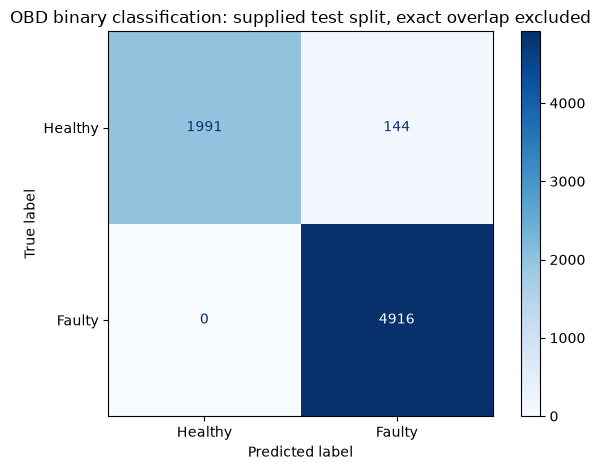

In [7]:
binary_predictions = binary_model.predict(X_test)
comparison = []
for name, model in [("Most-frequent baseline", baseline), ("Random Forest", binary_model)]:
    predicted = model.predict(X_test)
    comparison.append({
        "model": name, "accuracy": accuracy_score(y_test, predicted),
        "balanced_accuracy": balanced_accuracy_score(y_test, predicted),
        "fault_precision": precision_score(y_test, predicted, zero_division=0),
        "fault_recall": recall_score(y_test, predicted, zero_division=0),
        "fault_f1": f1_score(y_test, predicted, zero_division=0),
    })
binary_metrics = pd.DataFrame(comparison).set_index("model")
display(binary_metrics)
print(classification_report(y_test, binary_predictions, labels=[0, 1],
                            target_names=["Healthy", "Faulty"], zero_division=0))
ConfusionMatrixDisplay.from_predictions(
    y_test, binary_predictions, labels=[0, 1], display_labels=["Healthy", "Faulty"], cmap="Blues",
)
plt.title("OBD binary classification: supplied test split, exact overlap excluded")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "binary_confusion_matrix.png", dpi=160)
plt.show()

## 8. 여러 고장 코드 동시 예측
RandomForestClassifier의 다중 출력 기능으로 원본 14개 P-code 라벨을 동시에 예측합니다. `P0000`도 원본 라벨로 보존합니다. 라벨이 서로 함께 나타나기 때문에 개별 코드의 성능이 독립적인 고장 원인 진단 능력을 의미하지는 않습니다.

Exact Match는 모든 코드가 맞은 행 비율, Hamming Loss는 전체 코드 판정 중 틀린 비율입니다. Macro F1은 코드별 F1의 평균이고 Micro F1은 전체 코드의 TP/FP/FN을 합쳐 계산합니다. 출력 간 제약을 강제하지 않아 P0000과 고장 코드가 동시에 예측되는 모순도 따로 집계합니다.

In [8]:
multi_model = make_forest()
multi_model.fit(X_train, Y_train)
Y_pred = multi_model.predict(X_test)
# 라벨별 최빈값만 출력하는 간단한 다중 라벨 기준 모델입니다.
majority_labels = Y_train.mode().iloc[0].to_numpy(dtype=int)
Y_baseline = np.tile(majority_labels, (len(Y_test), 1))

def multilabel_scores(truth, predicted):
    return {
        "exact_match": accuracy_score(truth, predicted),
        "micro_f1": f1_score(truth, predicted, average="micro", zero_division=0),
        "macro_f1": f1_score(truth, predicted, average="macro", zero_division=0),
        "hamming_loss": hamming_loss(truth, predicted),
    }

multi_metrics = pd.DataFrame({
    "Most-frequent baseline": multilabel_scores(Y_test, Y_baseline),
    "Random Forest": multilabel_scores(Y_test, Y_pred),
}).T
display(multi_metrics)
per_code = pd.DataFrame(classification_report(
    Y_test, Y_pred, target_names=LABEL_COLS, output_dict=True, zero_division=0,
)).T.loc[LABEL_COLS]
display(per_code)
predicted_labels = pd.DataFrame(Y_pred, columns=LABEL_COLS, index=Y_test.index)
contradiction_count = int(predicted_labels["P0000"].eq(1).eq(
    predicted_labels[FAULT_COLS].any(axis=1)
).sum())
print("P0000과 고장 코드의 논리 모순 예측 행 수:", contradiction_count)
print("모든 코드가 0인 예측도 모순 집계에 포함됩니다.")

P0000과 고장 코드의 논리 모순 예측 행 수: 78
모든 코드가 0인 예측도 모순 집계에 포함됩니다.


,exact_match,micro_f1,macro_f1,hamming_loss
Most-frequent baseline,0.00000,0.000000,0.000000,0.168132
Random Forest,0.93703,0.963093,0.975094,0.012541


,precision,recall,f1-score,support
P0000,1.000000,0.792037,0.883952,2135.0
P0562,1.000000,1.000000,1.000000,879.0
P0113,0.810559,1.000000,0.895369,1566.0
P0102,0.810559,1.000000,0.895369,1566.0
P0403,1.000000,1.000000,1.000000,1201.0
P0404,1.000000,1.000000,1.000000,1201.0
P2562,0.954311,1.000000,0.976621,1295.0
P0234,1.000000,1.000000,1.000000,271.0
P2015,1.000000,1.000000,1.000000,1201.0
P2009,1.000000,1.000000,1.000000,1201.0


## 9. 어떤 센서가 모델 판단에 쓰였는지 보기
아래 값은 정상/고장 Random Forest의 불순도 감소 기반 중요도입니다. 인과관계나 실제 고장 원인을 증명하는 값은 아닙니다. 연속값의 종류가 많은 센서에 유리할 수 있습니다.

,importance
VPWR,0.256001
IAT,0.208729
AAT,0.172663
MAP,0.098213
BARO,0.071601
FRP,0.057348
ECT,0.054047
VSS,0.031029
MAF,0.026655
RPM,0.018085


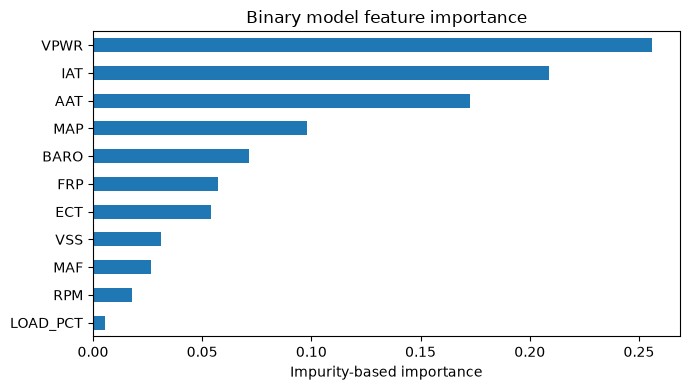

In [9]:
importance = pd.Series(
    binary_model.named_steps["classifier"].feature_importances_, index=SENSOR_COLS,
).sort_values(ascending=False)
display(importance.to_frame("importance"))
importance.sort_values().plot.barh(figsize=(7, 4), title="Binary model feature importance")
plt.xlabel("Impurity-based importance")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "feature_importance.png", dpi=160)
plt.show()

## 10. 테스트 예측 예시와 결과 저장
테스트에 있던 센서 행으로 입력 형식과 예측 결과를 확인합니다. 출력 확률은 모델 점수이며 실제 고장 발생 확률로 보정된 값은 아닙니다. 원본 엑셀은 수정하지 않습니다.

In [10]:
# 센서 열의 이름과 순서를 그대로 유지해야 합니다.
example = X_test.head(5)
example_prediction = pd.DataFrame({
    "source_row": test_clean.loc[example.index, "source_row"],
    "actual_fault": y_test.loc[example.index],
    "predicted_fault": binary_model.predict(example),
}, index=example.index)
classes = binary_model.named_steps["classifier"].classes_
if 1 in classes:
    fault_index = list(classes).index(1)
    example_prediction["fault_score"] = binary_model.predict_proba(example)[:, fault_index]
display(example.join(example_prediction))

binary_metrics.to_csv(OUTPUT_DIR / "binary_metrics.csv", encoding="utf-8-sig")
multi_metrics.to_csv(OUTPUT_DIR / "multilabel_metrics.csv", encoding="utf-8-sig")
per_code.to_csv(OUTPUT_DIR / "per_code_metrics.csv", encoding="utf-8-sig")
importance.to_csv(OUTPUT_DIR / "feature_importance.csv", encoding="utf-8-sig")
result = test_clean[["source_row"]].reset_index(drop=True)
result["actual_fault"] = y_test.to_numpy()
result["predicted_fault"] = binary_predictions
for i, label in enumerate(LABEL_COLS):
    result[f"actual_{label}"] = Y_test[label].to_numpy()
    result[f"predicted_{label}"] = Y_pred[:, i]
result.to_csv(OUTPUT_DIR / "test_predictions.csv", index=False, encoding="utf-8-sig")
# 이번 노트북에서 직접 학습한 모델과 입력 열 정보를 저장합니다.
joblib.dump({"binary_model": binary_model, "multilabel_model": multi_model,
             "sensor_columns": SENSOR_COLS, "label_columns": LABEL_COLS,
             "sklearn_version": sklearn.__version__}, OUTPUT_DIR / "obd_random_forest.joblib")
summary = {"source_commit": COMMIT, "random_state": SEED, "audit": audit,
           "binary_metrics": binary_metrics.to_dict(orient="index"),
           "multilabel_metrics": multi_metrics.to_dict(orient="index"),
           "contradictory_multilabel_predictions": contradiction_count,
           "limitation": "No vehicle ID or timestamps; not unseen-vehicle validation"}
(OUTPUT_DIR / "summary.json").write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8")
print("결과 저장 경로:", OUTPUT_DIR)

결과 저장 경로: /Users/hangyeonghyeon/Desktop/Py/python_study/results/test01


,LOAD_PCT,ECT,MAP,RPM,VSS,IAT,MAF,FRP,BARO,VPWR,AAT,source_row,actual_fault,predicted_fault,fault_score
1252,99.6,205,29.3,2081,72.405,108,0.11,18972.8,14.5,12.4,126,1252,1,1,1.0
1253,99.6,205,32.6,2081,72.405,108,0.11,18972.8,14.5,12.4,126,1253,1,1,1.0
1254,99.6,205,32.6,2504,72.405,108,0.11,18972.8,14.5,12.4,126,1254,1,1,1.0
1255,99.6,205,32.6,2504,88.495,108,0.11,18972.8,14.5,12.4,126,1255,1,1,1.0
1256,99.6,205,32.6,2504,88.495,118,0.11,18972.8,14.5,12.4,126,1256,1,1,1.0


## 해석과 다음 단계

전체 셀을 실행하면 다운로드 → 구조 점검 → 정답 누출 방지 → 중복 점검 → 기준 모델 비교 → 정상/고장 및 다중 코드 학습 → 테스트 평가를 수행합니다.

이번 데이터는 차량 수가 적고 고장 코드들이 특정 차량에서 함께 나타납니다. 따라서 높은 점수가 나와도 새로운 차량의 고장을 같은 수준으로 진단한다고 결론 내릴 수 없습니다. 차량 ID와 측정 세션/시간이 포함된 원본을 확보하면 차량 단위 분리 평가를 추가하세요. 단위 확인과 별도 검증 세트 확보 이후 XGBoost 등의 모델을 비교할 수 있습니다. 테스트 세트를 반복 튜닝에 쓰면 점수를 낙관적으로 해석하게 됩니다.